
CIFAR-10-C  ·  Out-of-Distribution Conformal Prediction
=========================================================
Goal
----
Show what happens to split-conformal coverage guarantees when the
*original* (clean) images were **never** exposed to the model during
training and the test distribution is shifted by image corruptions.

Protocol
--------
1. Train a small CNN on the **clean** CIFAR-10 *training* split (50 k images).
   → The model has never seen the CIFAR-10 test images in any form.

2. Calibrate conformal prediction on the **clean** CIFAR-10 *test* split
   (first half of the 10 k test images, split 50/50 cal/test).
   → q̂ is anchored to the clean-data distribution.

3. Evaluate on CIFAR-10-C at every corruption type and all 5 severity
   levels (these are corruptions of the CIFAR-10 test images the model has
   never seen clean).
   → Coverage degrades as severity rises — illustrating covariate shift.


In [ ]:

# ── Imports ───────────────────────────────────────────────────────────────────
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
ALPHA      = 0.10   # target miscoverage level
EPOCHS     = 10
BATCH_SIZE = 128
SEED       = 42

# Path to CIFAR-10-C .npy files
DATA_C_DIR = "/data/CIFAR-10-C"
if not os.path.exists(DATA_C_DIR):
    candidate = "./data/CIFAR-10-C"
    DATA_C_DIR = candidate if os.path.exists(candidate) else "./playground/data/CIFAR-10-C"

print("CIFAR-10-C dir :", DATA_C_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device         :", device)

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# All CIFAR-10-C corruption types present in the directory
CORRUPTIONS = sorted([
    f[:-4] for f in os.listdir(DATA_C_DIR)
    if f.endswith(".npy") and f != "labels.npy"
])
print(f"Found {len(CORRUPTIONS)} corruption types:", CORRUPTIONS)


CIFAR-10-C dir : ./data/CIFAR-10-C
Device         : cpu
Found 19 corruption types: ['brightness', 'contrast', 'defocus_blur', 'elastic_transform', 'fog', 'frost', 'gaussian_blur', 'gaussian_noise', 'glass_blur', 'impulse_noise', 'jpeg_compression', 'motion_blur', 'pixelate', 'saturate', 'shot_noise', 'snow', 'spatter', 'speckle_noise', 'zoom_blur']


In [3]:
# ── 1.  Clean CIFAR-10 – train & calibration/test loaders ────────────────────
# Standard normalisation for CIFAR-10
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

train_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean, std),
])
test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std),
])

clean_train_ds = torchvision.datasets.CIFAR10(
    root="./data", train=True,  download=True, transform=train_transform)
clean_test_ds  = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform)

# Split the 10 k test images 50/50 → calibration set | hold-out test set
generator = torch.Generator().manual_seed(SEED)
n_test   = len(clean_test_ds)
cal_size  = n_test // 2
test_size = n_test - cal_size
clean_cal_ds, clean_test_hold_ds = random_split(
    clean_test_ds, [cal_size, test_size], generator=generator)

train_loader     = DataLoader(clean_train_ds,     batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
cal_loader_clean = DataLoader(clean_cal_ds,        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_clean= DataLoader(clean_test_hold_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train  : {len(clean_train_ds):,}")
print(f"Cal    : {len(clean_cal_ds):,}  (clean test)")
print(f"Test   : {len(clean_test_hold_ds):,}  (clean test hold-out)")


100.0%
C:\Users\joobzm\Desktop\dacal-stream-learning\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train  : 50,000
Cal    : 5,000  (clean test)
Test   : 5,000  (clean test hold-out)


In [4]:
# ── 2.  Model definition ──────────────────────────────────────────────────────
class SimpleCNN(nn.Module):
    """Lightweight CNN – same architecture as the baseline notebook."""
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


model     = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()


In [5]:
# ── 3.  Training helpers ──────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits = model(X_b)
        loss   = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct    += (logits.argmax(1) == y_b).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            total_loss += criterion(logits, y_b).item() * len(y_b)
            correct    += (logits.argmax(1) == y_b).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n



In [6]:
# ── 4.  Train on clean CIFAR-10 ───────────────────────────────────────────────
print("─" * 60)
print(" Training on CLEAN CIFAR-10 train split")
print("─" * 60)
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, cal_loader_clean, criterion)
    scheduler.step()
    print(f"Epoch {epoch:2d}/{EPOCHS} │ "
          f"Train loss {tr_loss:.4f}  acc {tr_acc:.3f} │ "
          f"Clean-cal loss {va_loss:.4f}  acc {va_acc:.3f}")


────────────────────────────────────────────────────────────
 Training on CLEAN CIFAR-10 train split
────────────────────────────────────────────────────────────
Epoch  1/10 │ Train loss 1.4515  acc 0.468 │ Clean-cal loss 1.2969  acc 0.537
Epoch  2/10 │ Train loss 1.1205  acc 0.597 │ Clean-cal loss 0.9820  acc 0.656
Epoch  3/10 │ Train loss 1.0019  acc 0.643 │ Clean-cal loss 0.8084  acc 0.716
Epoch  4/10 │ Train loss 0.9224  acc 0.673 │ Clean-cal loss 0.7655  acc 0.734
Epoch  5/10 │ Train loss 0.8552  acc 0.699 │ Clean-cal loss 0.7657  acc 0.730
Epoch  6/10 │ Train loss 0.8063  acc 0.717 │ Clean-cal loss 0.7357  acc 0.734
Epoch  7/10 │ Train loss 0.7619  acc 0.734 │ Clean-cal loss 0.6873  acc 0.760
Epoch  8/10 │ Train loss 0.7186  acc 0.747 │ Clean-cal loss 0.6351  acc 0.776
Epoch  9/10 │ Train loss 0.7001  acc 0.755 │ Clean-cal loss 0.6080  acc 0.784
Epoch 10/10 │ Train loss 0.6821  acc 0.761 │ Clean-cal loss 0.5991  acc 0.786


In [7]:
# ── 5.  Conformal calibration on CLEAN images ─────────────────────────────────
# Non-conformity score: s(x, y) = 1 − softmax(f(x))[y]
model.eval()
cal_scores_clean = []
with torch.no_grad():
    for X_b, y_b in cal_loader_clean:
        probs = torch.softmax(model(X_b.to(device)), dim=1).cpu()
        s_i   = 1.0 - probs[torch.arange(len(y_b)), y_b]
        cal_scores_clean.append(s_i)

cal_scores_clean = torch.cat(cal_scores_clean)          # (n_cal,)

n_cal = len(cal_scores_clean)
k     = min(math.ceil((n_cal + 1) * (1 - ALPHA)), n_cal)
q_hat = cal_scores_clean.sort().values[k - 1].item()

print(f"\nCalibration quantile  q̂ = {q_hat:.4f}")
print(f"  α = {ALPHA},  n_cal = {n_cal},  k = {k}")



Calibration quantile  q̂ = 0.8291
  α = 0.1,  n_cal = 5000,  k = 4501


In [8]:
# ── 6.  Conformal evaluation helper ───────────────────────────────────────────
def conformal_eval(model, loader, q_hat: float, device):
    """Return (coverage, avg_set_size) given a pre-computed q̂."""
    model.eval()
    covered, total, set_sizes = 0, 0, []
    with torch.no_grad():
        for X_b, y_b in loader:
            probs     = torch.softmax(model(X_b.to(device)), dim=1).cpu()
            s_matrix  = 1.0 - probs                         # (B, C)
            pred_sets = s_matrix <= q_hat                   # (B, C)
            covered  += pred_sets[torch.arange(len(y_b)), y_b].sum().item()
            set_sizes.extend(pred_sets.sum(1).tolist())
            total    += len(y_b)
    return covered / total, sum(set_sizes) / len(set_sizes)


# Baseline – clean hold-out (should be ≥ 1 − α by construction)
cov_clean, sz_clean = conformal_eval(model, test_loader_clean, q_hat, device)
print(f"\nClean hold-out  →  coverage {cov_clean:.4f}  (target ≥ {1-ALPHA:.2f}),  avg set size {sz_clean:.3f}")



Clean hold-out  →  coverage 0.8936  (target ≥ 0.90),  avg set size 1.405


In [9]:
# ── 7.  Utility: build a DataLoader from a CIFAR-10-C severity slice ──────────
# CIFAR-10-C stores 5 severity levels stacked: indices [0..9999] = sev 1,
# [10000..19999] = sev 2 … [40000..49999] = sev 5.
# The labels.npy repeats the same 10 k test labels five times.

def load_corrupted_loader(corruption: str, severity: int,
                          data_dir: str, mean, std,
                          batch_size: int = 256):
    """Return a DataLoader for one (corruption, severity) pair."""
    assert 1 <= severity <= 5
    X_all = np.load(os.path.join(data_dir, f"{corruption}.npy"))   # (50000, 32, 32, 3)
    y_all = np.load(os.path.join(data_dir, "labels.npy"))          # (50000,)

    start = (severity - 1) * 10_000
    end   = start + 10_000
    X_sev = X_all[start:end]          # (10000, 32, 32, 3)  uint8
    y_sev = y_all[start:end]          # (10000,)

    # Apply the same standardisation used at clean-test time
    X_t = torch.tensor(X_sev, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    mu  = torch.tensor(mean).view(3, 1, 1)
    sig = torch.tensor(std).view(3, 1, 1)
    X_t = (X_t - mu) / sig

    y_t = torch.tensor(y_sev, dtype=torch.long)
    ds  = torch.utils.data.TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)


In [10]:
# ── 8.  Sweep all corruptions × all severities ────────────────────────────────
print("\nSweep  (q̂ calibrated on CLEAN data,  model trained on CLEAN train split)")
print("─" * 72)
print(f"{'Corruption':<22}  {'Sev 1':>7}  {'Sev 2':>7}  {'Sev 3':>7}  {'Sev 4':>7}  {'Sev 5':>7}  {'Mean':>7}")
print("─" * 72)

results = {}   # corruption → list of coverage per severity

for corruption in CORRUPTIONS:
    covs = []
    for sev in range(1, 6):
        loader = load_corrupted_loader(corruption, sev, DATA_C_DIR, mean, std, BATCH_SIZE)
        cov, _  = conformal_eval(model, loader, q_hat, device)
        covs.append(cov)
    results[corruption] = covs
    row = "  ".join(f"{c:7.4f}" for c in covs)
    print(f"{corruption:<22}  {row}  {sum(covs)/len(covs):7.4f}")

print("─" * 72)
print(f"{'Clean hold-out':<22}  {'—':>7}  {'—':>7}  {'—':>7}  {'—':>7}  {'—':>7}  {cov_clean:7.4f}")
print(f"\nTarget coverage ≥ {1-ALPHA:.2f}  (α = {ALPHA})")



Sweep  (q̂ calibrated on CLEAN data,  model trained on CLEAN train split)
────────────────────────────────────────────────────────────────────────
Corruption                Sev 1    Sev 2    Sev 3    Sev 4    Sev 5     Mean
────────────────────────────────────────────────────────────────────────
brightness               0.8957   0.8893   0.8840   0.8719   0.8475   0.8777
contrast                 0.8816   0.7674   0.6584   0.5242   0.3878   0.6439
defocus_blur             0.8960   0.8766   0.8367   0.7800   0.6840   0.8147
elastic_transform        0.8519   0.8520   0.8248   0.8112   0.8162   0.8312
fog                      0.8891   0.8634   0.8234   0.7608   0.6043   0.7882
frost                    0.8652   0.8107   0.7229   0.7073   0.6071   0.7426
gaussian_blur            0.8963   0.8348   0.7824   0.7320   0.6371   0.7765
gaussian_noise           0.7505   0.6010   0.5010   0.4711   0.4427   0.5533
glass_blur               0.6949   0.7170   0.7719   0.5962   0.6516   0.6863
impulse_n

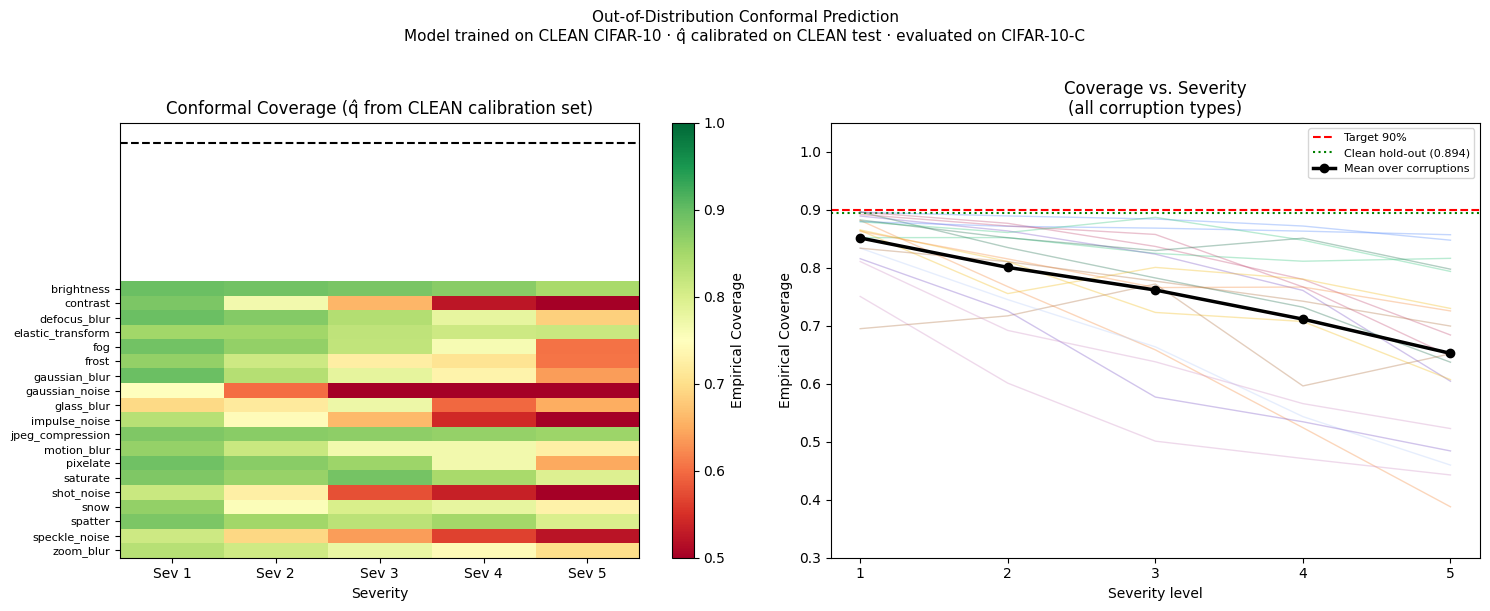

Figure saved to ood_conformal_coverage.png


In [11]:
# ── 9.  Visualisation ─────────────────────────────────────────────────────────
severities = list(range(1, 6))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: heatmap  (corruption × severity)
import matplotlib.colors as mcolors

cov_matrix = np.array([results[c] for c in CORRUPTIONS])   # (n_corr, 5)
vmin, vmax = 0.5, 1.0
im = axes[0].imshow(cov_matrix, aspect='auto', vmin=vmin, vmax=vmax,
                    cmap='RdYlGn',
                    extent=[0.5, 5.5, len(CORRUPTIONS) - 0.5, -0.5])
axes[0].set_xticks(severities)
axes[0].set_xticklabels([f"Sev {s}" for s in severities])
axes[0].set_yticks(range(len(CORRUPTIONS)))
axes[0].set_yticklabels(CORRUPTIONS, fontsize=8)
axes[0].set_xlabel("Severity")
axes[0].set_title("Conformal Coverage (q̂ from CLEAN calibration set)")
plt.colorbar(im, ax=axes[0], label="Empirical Coverage")
axes[0].axhline(-0.5, color='white', lw=0)   # padding
target_line = axes[0].axhline(-10, color='black', lw=1.5, ls='--', label=f'Target {1-ALPHA:.0%}')

# Right: mean coverage vs. severity, per corruption type
mean_cov_per_sev = cov_matrix.mean(axis=0)
axes[1].axhline(1 - ALPHA, color='red', ls='--', lw=1.5, label=f'Target {1-ALPHA:.0%}')
axes[1].axhline(cov_clean,  color='green', ls=':', lw=1.5, label=f'Clean hold-out ({cov_clean:.3f})')
for c in CORRUPTIONS:
    axes[1].plot(severities, results[c], alpha=0.35, lw=1)
axes[1].plot(severities, mean_cov_per_sev, color='black', lw=2.5, marker='o', label='Mean over corruptions')
axes[1].set_xlabel("Severity level")
axes[1].set_ylabel("Empirical Coverage")
axes[1].set_title("Coverage vs. Severity\n(all corruption types)")
axes[1].legend(fontsize=8)
axes[1].set_xticks(severities)
axes[1].set_ylim(0.3, 1.05)

plt.suptitle(
    "Out-of-Distribution Conformal Prediction\n"
    "Model trained on CLEAN CIFAR-10 · q̂ calibrated on CLEAN test · evaluated on CIFAR-10-C",
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("ood_conformal_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to ood_conformal_coverage.png")


In [12]:
# ── 10.  Per-class coverage breakdown for a single (corruption, severity) ─────
TARGET_CORRUPTION = "gaussian_noise"
TARGET_SEVERITY   = 3

loader_spot = load_corrupted_loader(
    TARGET_CORRUPTION, TARGET_SEVERITY, DATA_C_DIR, mean, std, BATCH_SIZE)

model.eval()
class_covered = [0] * 10
class_total   = [0] * 10
with torch.no_grad():
    for X_b, y_b in loader_spot:
        probs     = torch.softmax(model(X_b.to(device)), dim=1).cpu()
        s_matrix  = 1.0 - probs
        pred_sets = s_matrix <= q_hat
        for i, y_true in enumerate(y_b):
            c = y_true.item()
            class_covered[c] += int(pred_sets[i, c].item())
            class_total[c]   += 1

print(f"\nPer-class coverage  ·  {TARGET_CORRUPTION}  severity {TARGET_SEVERITY}")
print(f"  (q̂ = {q_hat:.4f}  calibrated on CLEAN CIFAR-10 test images)\n")
for i, cls in enumerate(CLASSES):
    bar = "█" * int(class_covered[i] / class_total[i] * 30)
    print(f"  {cls:<12} {class_covered[i]/class_total[i]:.3f}  {bar}")



Per-class coverage  ·  gaussian_noise  severity 3
  (q̂ = 0.8291  calibrated on CLEAN CIFAR-10 test images)

  airplane     0.140  ████
  automobile   0.440  █████████████
  bird         0.223  ██████
  cat          0.507  ███████████████
  deer         0.758  ██████████████████████
  dog          0.073  ██
  frog         0.986  █████████████████████████████
  horse        0.290  ████████
  ship         0.717  █████████████████████
  truck        0.876  ██████████████████████████


In [13]:
# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Model       : SimpleCNN   trained on CLEAN CIFAR-10 train")
print(f"  q̂ source    : CLEAN CIFAR-10 test (first {cal_size} images)")
print(f"  ALPHA       : {ALPHA}")
print(f"  q̂           : {q_hat:.4f}")
print(f"  Clean cov.  : {cov_clean:.4f}  {'✓ OK' if cov_clean >= 1-ALPHA else '✗ VIOLATION'}")
avgs = {c: sum(v)/len(v) for c, v in results.items()}
worst = min(avgs, key=avgs.get)
best  = max(avgs, key=avgs.get)
print(f"  Best  corr. : {best:<22} mean cov {avgs[best]:.4f}")
print(f"  Worst corr. : {worst:<22} mean cov {avgs[worst]:.4f}")
print(f"  Overall mean: {sum(avgs.values())/len(avgs):.4f}")
print("=" * 60)
print("\nKey takeaway:")
print("  The coverage guarantee holds by construction on the clean")
print("  calibration distribution, but degrades under covariate shift")
print("  (corruptions) — especially at higher severity levels — because")
print("  the exchangeability assumption of split conformal is violated.")



SUMMARY
  Model       : SimpleCNN   trained on CLEAN CIFAR-10 train
  q̂ source    : CLEAN CIFAR-10 test (first 5000 images)
  ALPHA       : 0.1
  q̂           : 0.8291
  Clean cov.  : 0.8936  ✗ VIOLATION
  Best  corr. : brightness             mean cov 0.8777
  Worst corr. : gaussian_noise         mean cov 0.5533
  Overall mean: 0.7554

Key takeaway:
  The coverage guarantee holds by construction on the clean
  calibration distribution, but degrades under covariate shift
  (corruptions) — especially at higher severity levels — because
  the exchangeability assumption of split conformal is violated.
